## Customer Churn Prediction

In this project i am trying to predict which customers 
are likely to leave the telecom company. 

The dataset i used is Telco Customer Churn from Kaggle 
which has 7043 customers and 21 columns.

My goal is to build a model that can help the company 
identify high risk customers before they actually leave.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
# loading the data first
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# just checking how many rows and columns we have
print(df.shape)

# looking at first few rows to understand the data
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
# checking how many customers churned vs stayed
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

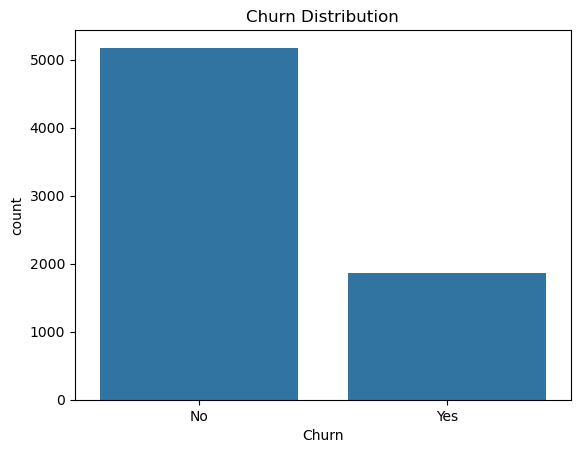

In [6]:
# visualizing churn distribution
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


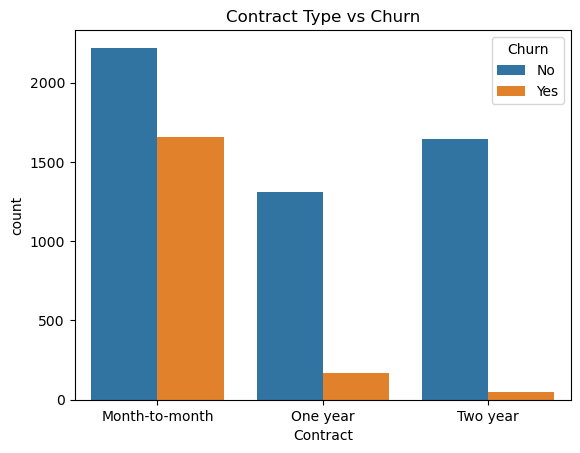

In [9]:
# checking which contract type has more churn
# month to month customers might be leaving more
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.show()

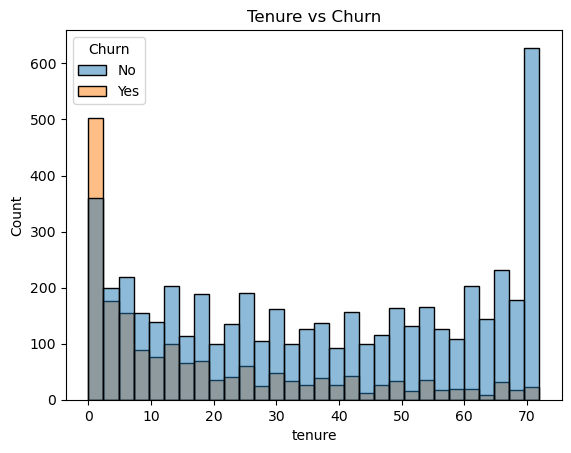

In [10]:
# checking if new customers churn more than old customers
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.title('Tenure vs Churn')
plt.show()

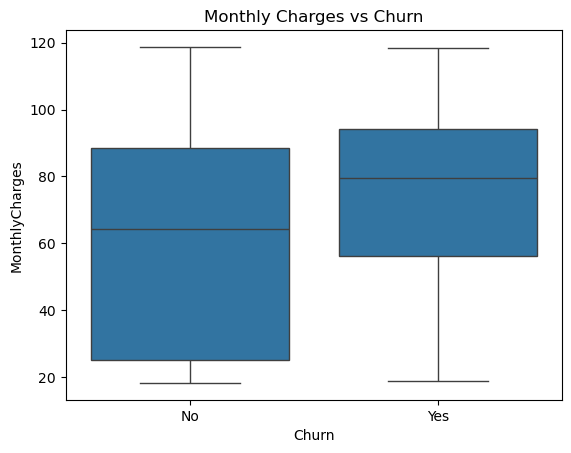

In [11]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

- This heatmap only shows numeric columns
- Categorical columns like contract type are not shown here
- But their relationship with churn is shown in the plots above

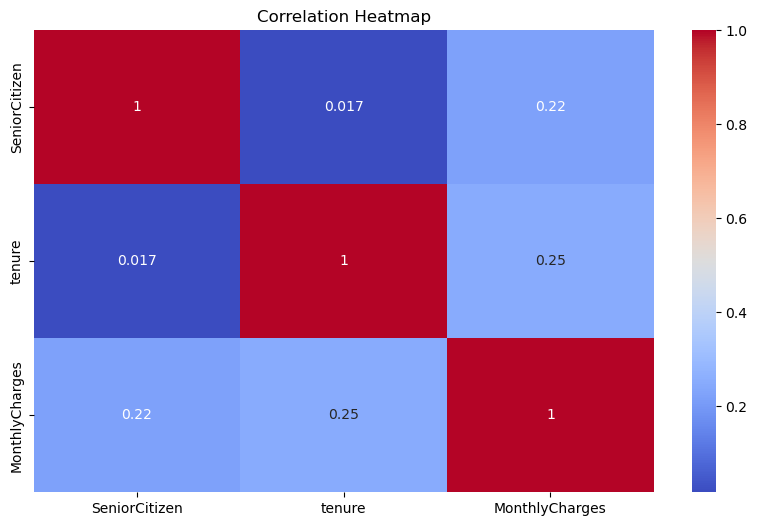

In [12]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## What i found in EDA

- around 26% customers have churned which means the 
  data is imbalanced
- customers with month to month contract are churning 
  more compared to 1 or 2 year contracts
- customers with high monthly charges tend to churn more
- new customers (low tenure) are leaving more than 
  older customers
- these patterns make sense from a business perspective 
  because new customers haven't built loyalty yet

## Data Cleaning and Preprocessing

before building the model i had to clean and prepare the data

In [13]:
# first i tried without converting TotalCharges and got error
# then realized it was stored as object type so converting it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
# removing the 11 null rows we found after conversion
df.dropna(inplace=True)
print(df.shape)

(7032, 21)


In [15]:
df.drop('customerID', axis=1, inplace=True)
print(df.shape)

(7032, 20)


In [16]:
# converting yes/no to 1/0 so model can understand it
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [17]:
# converting all categorical columns to numbers
df = pd.get_dummies(df, drop_first=True)
print(df.shape)
print(df.head())

(7032, 31)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                   

In [18]:
X = df.drop('Churn', axis=1)
y = df['Churn']
print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5625, 30)
Test size: (1407, 30)


In [20]:
# scaling the features so all values are in same range
# logistic regression needs this
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Scaling done")

Scaling done


In [21]:
# starting with simple model first as baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

lr_model = LogisticRegression(max_iter=2000, class_weight='balanced')
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]))
print("\n", classification_report(y_test, lr_pred))
                                 
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# putting scaler and model together in a pipeline
# this way scaling happens properly in each fold
cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

cv_scores = cross_val_score(cv_pipeline, X, y, cv=5, scoring='roc_auc')

print("CV Scores each fold:", cv_scores)
print("Average ROC-AUC:", cv_scores.mean().round(3))
print("Std Deviation:", cv_scores.std().round(3))

Accuracy: 0.7313432835820896
ROC-AUC: 0.8316284535463399

               precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

CV Scores each fold: [0.85780992 0.85910929 0.83476508 0.83563922 0.83890893]
Average ROC-AUC: 0.845
Std Deviation: 0.011


- I wanted to see if my model is getting lucky on just one
particular split of data. So I tried something called cross validation.

- Instead of splitting data once, it splits the data into 5 parts and 
tests the model 5 times on different splits and takes the average.

- My model got 0.845 average ROC-AUC across all 5 folds and std 
deviation is only 0.011 which means the model is giving consistent 
results every time and I can trust these numbers.

In [22]:
# trying random forest to see if it does better than logistic regression
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))
print("\n", classification_report(y_test, rf_pred))

Accuracy: 0.7846481876332623
ROC-AUC: 0.8153358941041875

               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [23]:
# trying xgboost which is usually the best model
# had to install it separately using pip install xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))
print("\n", classification_report(y_test, xgb_pred))

Accuracy: 0.7739872068230277
ROC-AUC: 0.8108152880090697

               precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.69      1407
weighted avg       0.76      0.77      0.77      1407



In [24]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
    ]
})
print(results)

                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.731343  0.831628
1        Random Forest  0.784648  0.815336
2              XGBoost  0.773987  0.810815


## Models I tried

I built 3 models to compare which one works best as shown in above

1. Logistic Regression - simple baseline model
2. Random Forest - handles complex patterns better
3. XGBoost - advanced model, I had to install it separately

Surprisingly logistic regression gave the best ROC-AUC 
score of 0.83 which means simpler model worked better 
here. This could be because the churn patterns in this 
data are mostly linear.

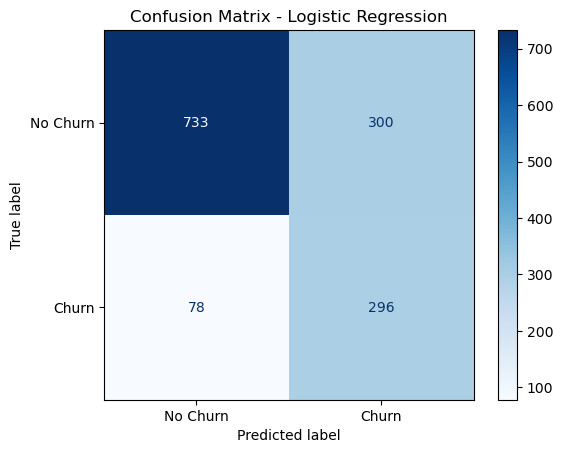

In [25]:
# confusion matrix shows exactly where model is making mistakes
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

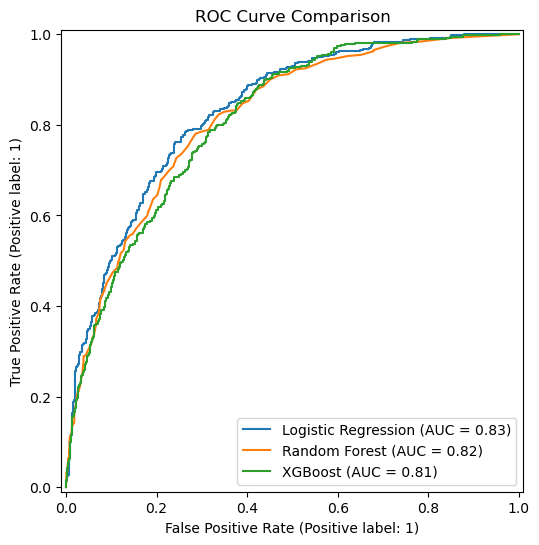

In [26]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8,6))

RocCurveDisplay.from_estimator(lr_model, X_test, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=ax, name='Random Forest')
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, ax=ax, name='XGBoost')

plt.title('ROC Curve Comparison')
plt.show()

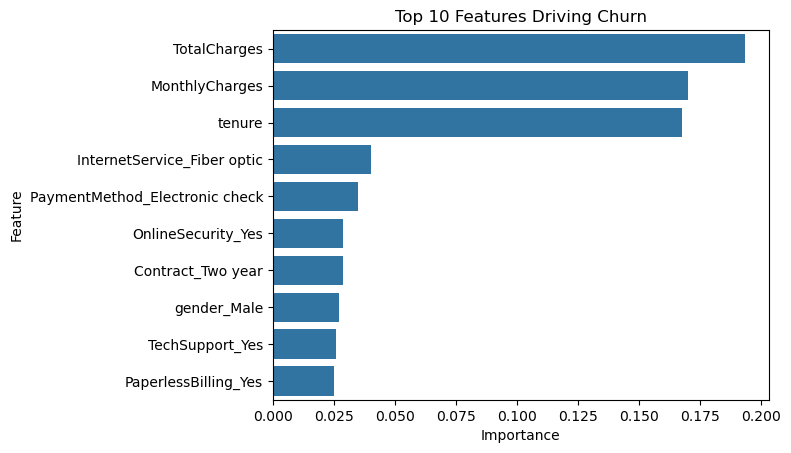

In [27]:
# checking which features are most important for churn prediction
feature_importance = pd.DataFrame({
    'Feature': df.drop('Churn', axis=1).columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Top 10 Features Driving Churn')
plt.show()

In [28]:
# giving each customer a churn risk score
X_test_df = pd.DataFrame(X_test, columns=df.drop('Churn', axis=1).columns)
X_test_df['Churn_Probability'] = lr_model.predict_proba(X_test)[:,1]
X_test_df['Churn_Prediction'] = lr_pred

def risk_category(prob):
    if prob >= 0.5:
        return 'High Risk'
    elif prob >= 0.3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

X_test_df['Risk_Category'] = X_test_df['Churn_Probability'].apply(risk_category)
print(X_test_df['Risk_Category'].value_counts())

Risk_Category
Low Risk       596
High Risk      596
Medium Risk    215
Name: count, dtype: int64


- customers with more than 50% chance of leaving are High Risk
- customers with 30% to 50% chance are Medium Risk, they might leave
- customers with less than 30% chance are Low Risk, they are safe

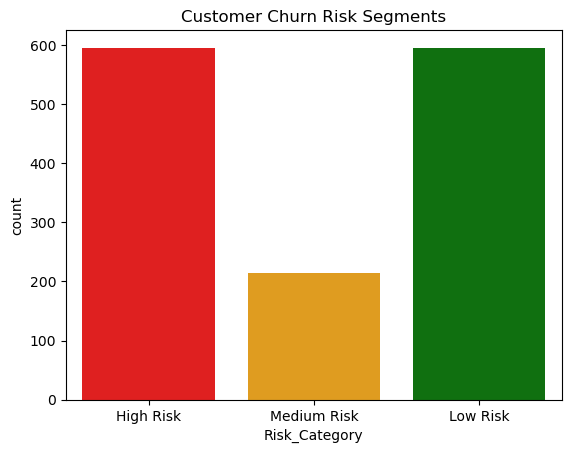

In [29]:
# visualizing how many customers fall in each risk category
sns.countplot(x='Risk_Category', data=X_test_df,
              order=['High Risk', 'Medium Risk', 'Low Risk'],
              hue='Risk_Category',
              palette={'High Risk':'red', 'Medium Risk':'orange', 'Low Risk':'green'},
              legend=False)
plt.title('Customer Churn Risk Segments')
plt.show()

In [30]:
total = len(X_test_df)
high_risk = len(X_test_df[X_test_df['Risk_Category'] == 'High Risk'])
medium_risk = len(X_test_df[X_test_df['Risk_Category'] == 'Medium Risk'])
low_risk = len(X_test_df[X_test_df['Risk_Category'] == 'Low Risk'])

print("=" * 45)
print("       CHURN PREDICTION SUMMARY")
print("=" * 45)
print(f"Total Customers Analyzed : {total}")
print(f"High Risk  (will churn)  : {high_risk} ({round(high_risk/total*100, 1)}%)")
print(f"Medium Risk              : {medium_risk} ({round(medium_risk/total*100, 1)}%)")
print(f"Low Risk   (safe)        : {low_risk} ({round(low_risk/total*100, 1)}%)")
print("=" * 45)
print(f"Model ROC-AUC Score      : 0.845")
print(f"Recommended Action       : Target High Risk customers")
print(f"                           with retention offers")
print("=" * 45)

       CHURN PREDICTION SUMMARY
Total Customers Analyzed : 1407
High Risk  (will churn)  : 596 (42.4%)
Medium Risk              : 215 (15.3%)
Low Risk   (safe)        : 596 (42.4%)
Model ROC-AUC Score      : 0.845
Recommended Action       : Target High Risk customers
                           with retention offers


## Conclusion and Business Recommendation

I was actually surprised that logistic regression gave 
the best result because I expected xgboost to win since 
everyone says it is the most powerful model. But after 
seeing the results i understood that simpler models can 
work better when the data patterns are straightforward.

The model correctly identifies 79% of actual churners (recall = 0.79), 
with a ROC-AUC of 0.845 across 5 fold cross validation.

From the feature importance chart the main reasons 
customers are leaving are:
- MonthlyCharges is the top factor driving churn
- Customers using fiber optic internet churn more
- month to month contract customers are highest risk
- New customers with low tenure are leaving more than older customers
- I noticed TotalCharges is just MonthlyCharges multiplied by tenure 
so i did not treat it as a separate insight

My recommendation to the business:
- target the 311 high risk customers with special 
  discounts or offers before they leave
- try to move month to month customers to yearly contracts
- new customers in first 6 months need more attention 
  because tenure is a strong churn factor
- customers paying high monthly charges should be 
  offered better plans